In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df = pd.read_csv('heart.csv')

print("--- Dataset Preview ---")
display(df.head())


target_col = 'target' if 'target' in df.columns else df.columns[-1]

print(f"\nTarget Column identified as: '{target_col}'")
print(df[target_col].value_counts())

--- Dataset Preview ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Target Column identified as: 'target'
target
1    526
0    499
Name: count, dtype: int64


In [2]:
# Convert any categorical text columns to numeric using One-Hot Encoding
X = pd.get_dummies(df.drop(columns=[target_col]), drop_first=True)
y = df[target_col]

# Split the data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data: {X_train.shape[0]} samples")
print(f"Testing Data: {X_test.shape[0]} samples")

Training Data: 820 samples
Testing Data: 205 samples


In [3]:
# Train a fully grown Decision Tree (prone to overfitting)
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

# Check accuracy on train vs test
train_acc_full = accuracy_score(y_train, dt_full.predict(X_train))
test_acc_full = accuracy_score(y_test, dt_full.predict(X_test))

print("--- Fully Grown Decision Tree ---")
print(f"Training Accuracy: {train_acc_full:.4f} (Notice it is 1.0 or very close - Overfitting!)")
print(f"Testing Accuracy: {test_acc_full:.4f}")

# Train a pruned Decision Tree (Controlling tree depth to prevent overfitting)
dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pruned.fit(X_train, y_train)

train_acc_pruned = accuracy_score(y_train, dt_pruned.predict(X_train))
test_acc_pruned = accuracy_score(y_test, dt_pruned.predict(X_test))

print("\n--- Pruned Decision Tree (max_depth=3) ---")
print(f"Training Accuracy: {train_acc_pruned:.4f}")
print(f"Testing Accuracy: {test_acc_pruned:.4f} (Usually better or more stable general performance)")

--- Fully Grown Decision Tree ---
Training Accuracy: 1.0000 (Notice it is 1.0 or very close - Overfitting!)
Testing Accuracy: 0.9854

--- Pruned Decision Tree (max_depth=3) ---
Training Accuracy: 0.8451
Testing Accuracy: 0.8537 (Usually better or more stable general performance)


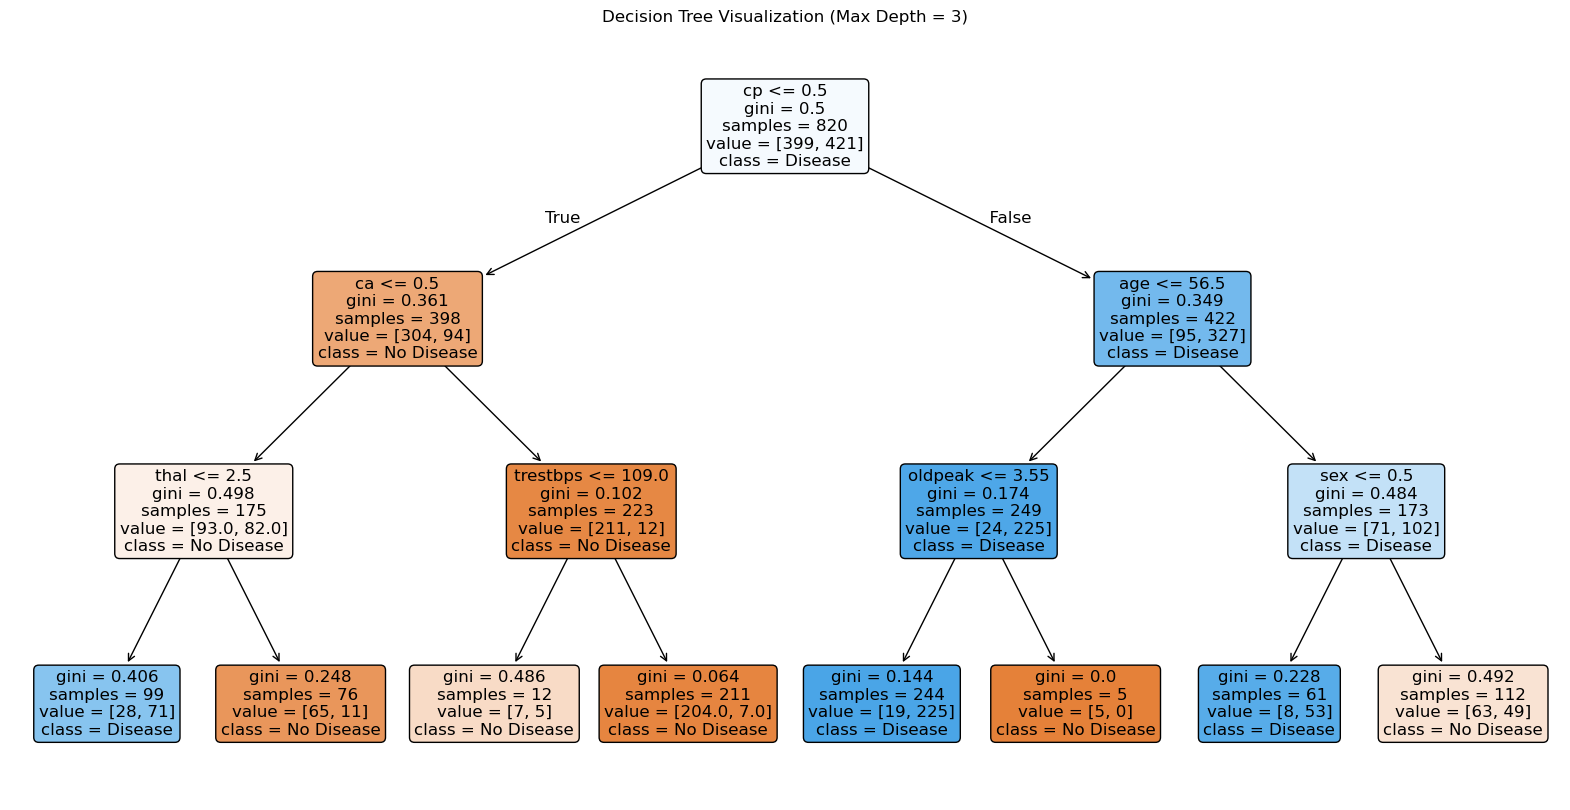

In [4]:
# Visualize the pruned decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_pruned, 
          feature_names=X.columns,  
          class_names=['No Disease', 'Disease'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Decision Tree Visualization (Max Depth = 3)")
plt.show()

In [5]:
# Train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("--- Random Forest Classifier ---")
print(f"Random Forest Testing Accuracy: {rf_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

# Compare the single pruned tree vs the random forest
print(f"Improvement over Single Pruned Tree: {(rf_acc - test_acc_pruned)*100:.2f}%")

--- Random Forest Classifier ---
Random Forest Testing Accuracy: 0.9268

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.92       100
           1       0.89      0.97      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205

Improvement over Single Pruned Tree: 7.32%


In [6]:
# Evaluate Random Forest using 5-Fold Cross-Validation for robust metrics
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print("--- 5-Fold Cross Validation (Random Forest) ---")
print(f"Individual Fold Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

--- 5-Fold Cross Validation (Random Forest) ---
Individual Fold Scores: [0.97073171 0.91219512 0.95121951 0.91219512 0.90243902]
Mean CV Accuracy: 0.9298
Standard Deviation: 0.0265


C:\Users\Anubhav\AppData\Local\Temp\ipykernel_1228\1784953644.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


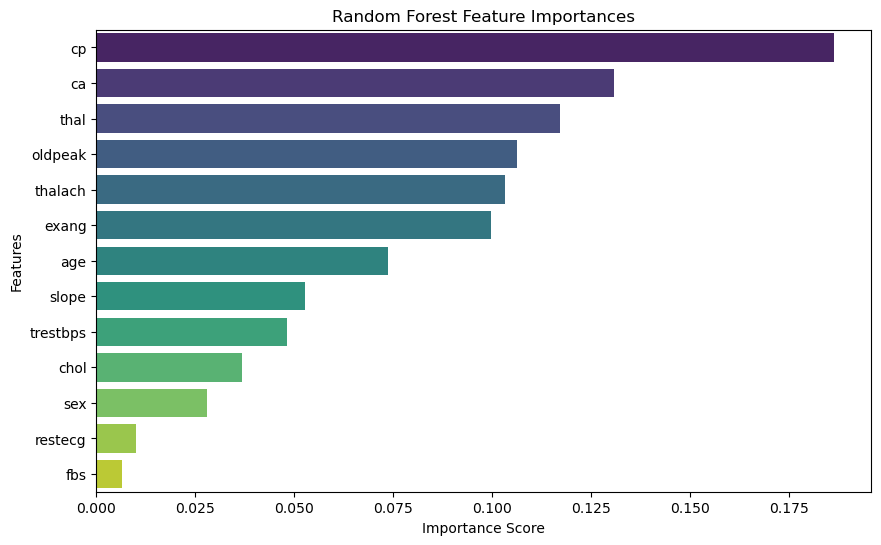

In [7]:
# Extract and visualize feature importances from the Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame and sort
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()